In [5]:
import pandas as pd
from sympy.printing.pretty.pretty_symbology import line_width

all_predict = pd.read_csv(r'predictions_gin_testdata283.csv')
all_predict.head()

,pre,real
0,0.997079,1.020015
1,2.027245,1.763455
2,0.047334,0.025805
3,1.486662,1.337370
4,0.276784,0.190488


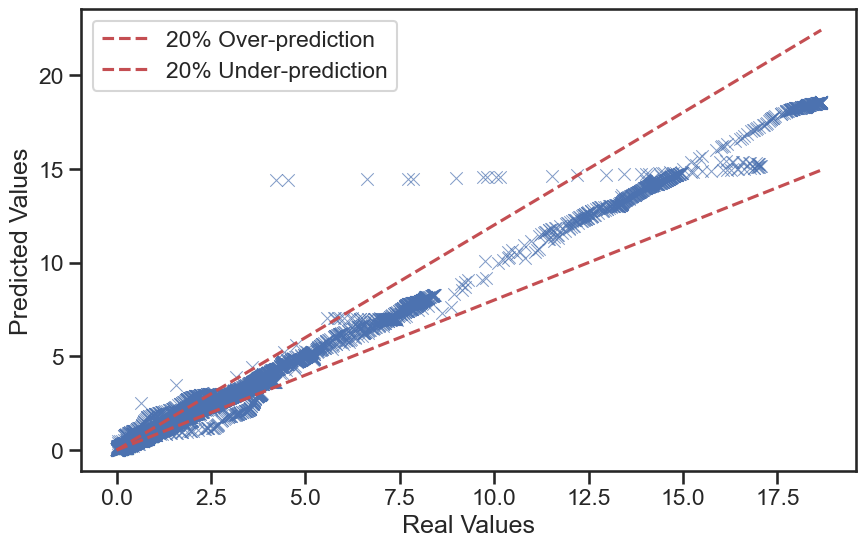

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set theme


# Create scatter plot with modifications
plt.figure(figsize=(10, 6))
sns.scatterplot(x='real', y='pre', data=all_predict, marker='x', alpha=0.7)

# Set labels
plt.xlabel('Real Values')
plt.ylabel('Predicted Values')

# # Set log scale for both axes
# plt.xscale('log')
# plt.yscale('log')

# Add 20% error lines
x_vals = np.linspace(all_predict['real'].min(), all_predict['real'].max(), 100)
plt.plot(x_vals, 1.2 * x_vals, 'r--', label='20% Over-prediction')
plt.plot(x_vals, 0.8 * x_vals, 'r--', label='20% Under-prediction')

# Set limits for zooming into a specific region (optional)
# plt.xlim(0, 3)
# plt.ylim(0, 3)

# Add legend
plt.legend()

# Show plot
plt.show()

In [7]:
select_pre = pd.read_csv(r'filtered_predictions_gin_testdata283.csv')
print(len(select_pre['pre']))
select_pre.head()

116


,pre,real
0,1.8080,1.6699
1,0.5120,0.4708
2,0.8408,0.9497
3,0.4640,0.4535
4,2.0528,1.8318


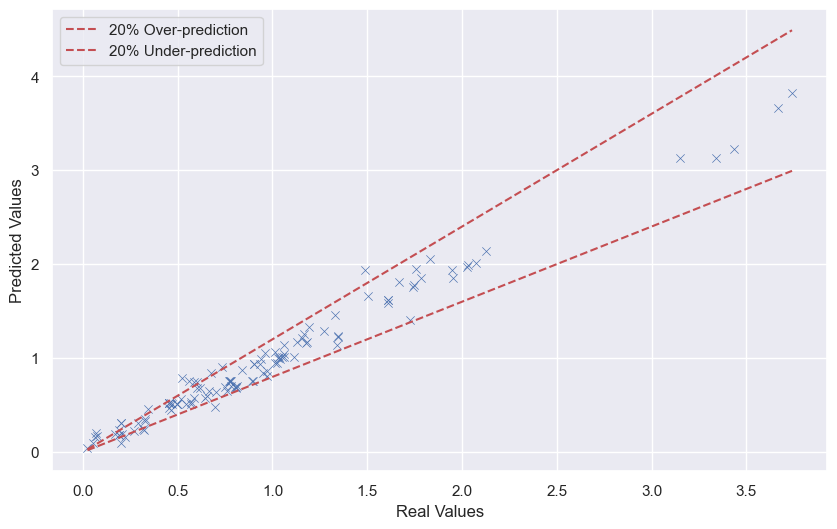

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set theme
sns.set_theme(style='darkgrid')

# Create scatter plot with modifications
plt.figure(figsize=(10, 6))
sns.scatterplot(x='real', y='pre', data=select_pre, marker='x')

# Set labels
plt.xlabel('Real Values')
plt.ylabel('Predicted Values')

# # Set log scale for both axes
# plt.xscale('log')
# plt.yscale('log')

# Add 20% error lines
x_vals = np.linspace(select_pre['real'].min(), select_pre['real'].max(), 100)
plt.plot(x_vals, 1.2 * x_vals, 'r--', label='20% Over-prediction')
plt.plot(x_vals, 0.8 * x_vals, 'r--', label='20% Under-prediction')

# Set limits for zooming into a specific region (optional)
# plt.xlim(0, 1)
# plt.ylim(0, 1)

# Add legend
plt.legend()

# Show plot
plt.show()

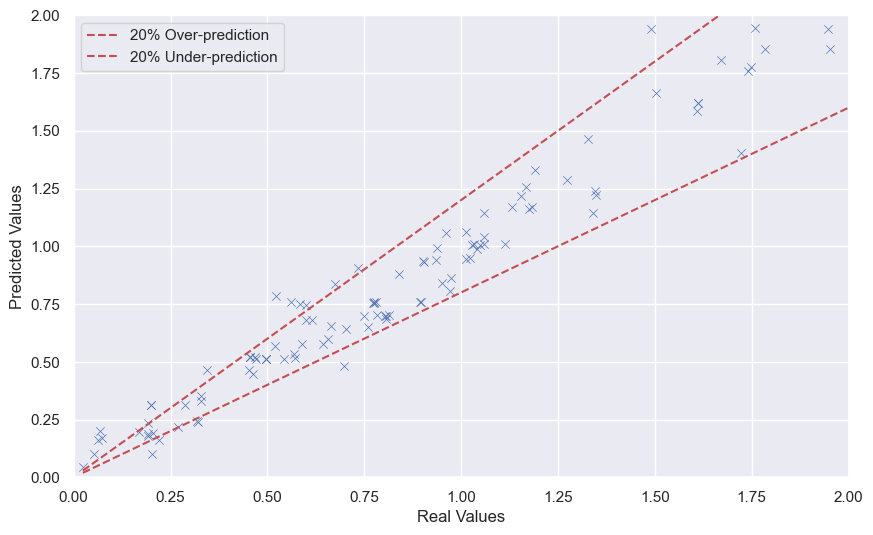

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set theme
sns.set_theme(style='darkgrid')

# Create scatter plot with modifications
plt.figure(figsize=(10, 6))
sns.scatterplot(x='real', y='pre', data=select_pre, marker='x')

# Set labels
plt.xlabel('Real Values')
plt.ylabel('Predicted Values')

# # Set log scale for both axes
# plt.xscale('log')
# plt.yscale('log')

# Add 20% error lines
x_vals = np.linspace(select_pre['real'].min(), select_pre['real'].max(), 100)
plt.plot(x_vals, 1.2 * x_vals, 'r--', label='20% Over-prediction')
plt.plot(x_vals, 0.8 * x_vals, 'r--', label='20% Under-prediction')

# Set limits for zooming into a specific region (optional)
plt.xlim(0, 2)
plt.ylim(0, 2)

# Add legend
plt.legend()

# Show plot
plt.show()

In [10]:
import pandas as pd
bad_pre_data = pd.read_csv(r'../../newdata/nosmooth/result/predictions_gin-1.csv')
random_indices = np.random.choice(bad_pre_data.index, size=148, replace=False)
bad_pre_data = bad_pre_data.drop(random_indices)
print(len(bad_pre_data['pre']))
bad_pre_data.head()

116


,pre,real
0,1.284025,0.51855
3,0.688611,0.75900
5,3.136633,2.57534
7,1.014420,0.33898
10,2.465670,2.40432


Mean Error: 0.36819
Relative Error: 90.56%
MSE: 0.45759
R²: 0.96527


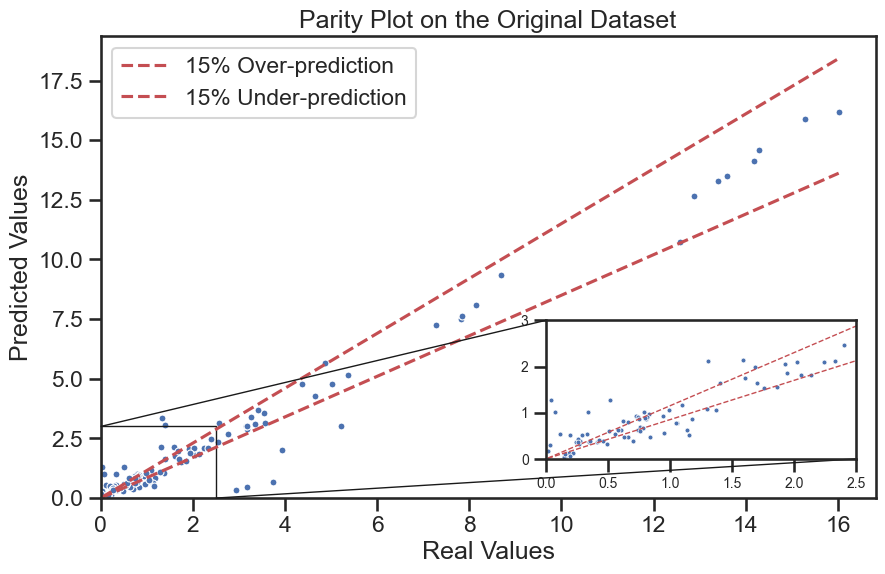

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

real_values = bad_pre_data['real']
pred_values = bad_pre_data['pre']
mean_error_dl = np.mean(abs(real_values - pred_values))
# max_error_dl = np.max(np.abs(real_values - pred_values))
relative_error_dl = np.mean(np.abs((real_values - pred_values) / real_values)) * 100
mse_dl = mean_squared_error(real_values, pred_values)
r2_dl = r2_score(real_values, pred_values)
print(f"Mean Error: {mean_error_dl:.5f}")
# print(f"Max Error: {max_error_dl:.5f}")
print(f"Relative Error: {relative_error_dl:.2f}%")
print(f"MSE: {mse_dl:.5f}")
print(f"R²: {r2_dl:.5f}")

# Set theme
sns.set_theme(style='ticks')
sns.set_context("talk")
# Create scatter plot with modifications
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.scatterplot(x='real', y='pre', data=bad_pre_data, s=100, marker='.')

# Set labels
plt.xlabel('Real Values')
plt.ylabel('Predicted Values')

# # Set log scale for both axes
# plt.xscale('log')
# plt.yscale('log')

# Add 20% error lines
x_vals = np.linspace(bad_pre_data['real'].min(), bad_pre_data['real'].max(), 100)
plt.plot(x_vals, 1.15 * x_vals, 'r--', label='15% Over-prediction')
plt.plot(x_vals, 0.85 * x_vals, 'r--', label='15% Under-prediction')
plt.legend()
plt.xlim(0, None)
plt.ylim(0, None)
plt.title('Parity Plot on the Original Dataset')

from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
axins = inset_axes(ax, width="40%", height="30%",loc='lower left',
                   bbox_to_anchor=(0.56, 0.06, 1, 1),
                   bbox_transform=ax.transAxes)
# Real values and predictions scatter plots

sns.scatterplot(x='real', y='pre', data=bad_pre_data,s=50, marker='.')
plt.plot(x_vals, 1.15 * x_vals, 'r--', label='15% Over-prediction', linewidth=1)
plt.plot(x_vals, 0.85 * x_vals, 'r--', label='15% Under-prediction', linewidth=1)

# 调整子坐标系的显示范围
axins.set_xlim(0, 2.5)
axins.set_ylim(0, 3)
# 建立父坐标系与子坐标系的连接线
# loc1 loc2: 坐标系的四个角
# 1 (右上) 2 (左上) 3(左下) 4(右下)
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec='k', lw=1)
plt.xlabel(None)
plt.ylabel(None)
plt.tick_params(labelsize=10)


# Show plot
plt.show()

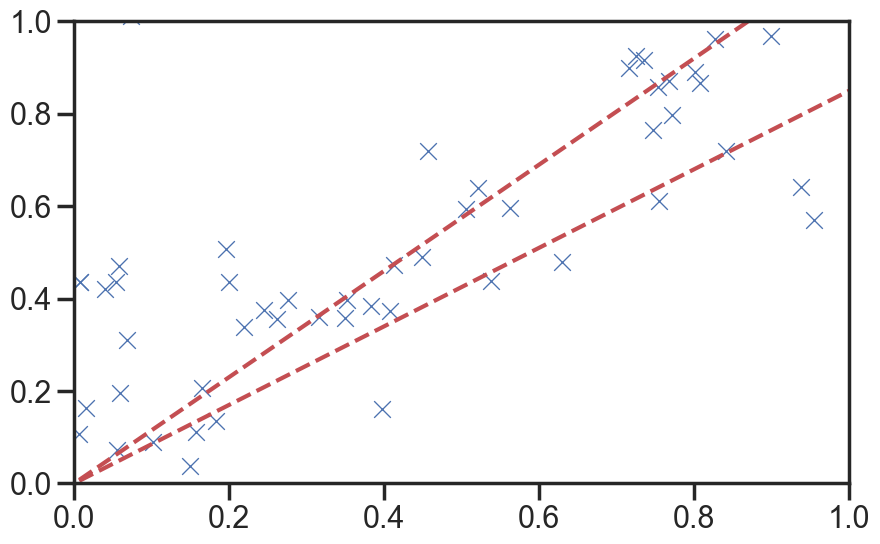

In [52]:
sns.set_theme(style='ticks')
sns.set_context("poster")
# Create scatter plot with modifications
plt.figure(figsize=(10, 6))
sns.scatterplot(x='real', y='pre', data=bad_pre_data, marker='x')

# Set labels
plt.xlabel(None)
plt.ylabel(None)

# # Set log scale for both axes
# plt.xscale('log')
# plt.yscale('log')

# Add 20% error lines
x_vals = np.linspace(bad_pre_data['real'].min(), bad_pre_data['real'].max(), 100)
plt.plot(x_vals, 1.15 * x_vals, 'r--', label='20% Over-prediction')
plt.plot(x_vals, 0.85 * x_vals, 'r--', label='20% Under-prediction')
# plt.title('Prediction vs Real')

# Set limits for zooming into a specific region (optional)
plt.xlim(0, 1)
plt.ylim(0, 1)

# Add legend
# plt.legend()
# Show plot
plt.show()

In [60]:
adsorption_test_pre = pd.read_csv('predictions_gin_test_323.csv')
adsorption_test_pre.head()

,pre,real,Pressure (bar),Adsorption (mmol/g)
0,0.375022,0.03729,0.00007,0.03729
1,0.438543,0.07410,0.00015,0.07410
2,0.493594,0.11335,0.00024,0.11335
3,0.536081,0.14967,0.00033,0.14967
4,0.575046,0.18512,0.00043,0.18512


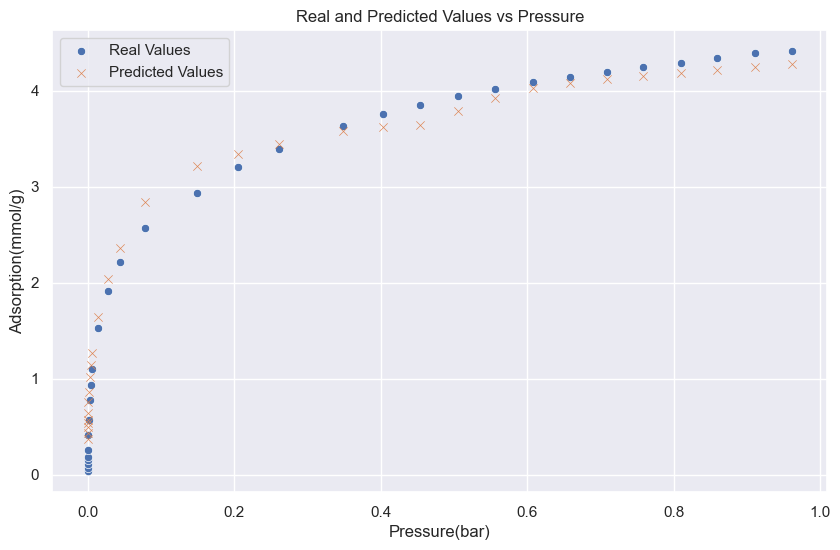

In [63]:

# Set theme
sns.set_theme(style='darkgrid')

# Create scatter plot with modifications
plt.figure(figsize=(10, 6))

# Plot real and predicted values on the same axes
sns.scatterplot(x='Pressure (bar)', y='real', data=adsorption_test_pre, label='Real Values', marker='o')
sns.scatterplot(x='Pressure (bar)', y='pre', data=adsorption_test_pre, label='Predicted Values', marker='x')

# Set labels
plt.xlabel('Pressure(bar)')
plt.ylabel('Adsorption(mmol/g)')
plt.title('Real and Predicted Values vs Pressure')

# Add legend
plt.legend()

# Show plot
plt.show()

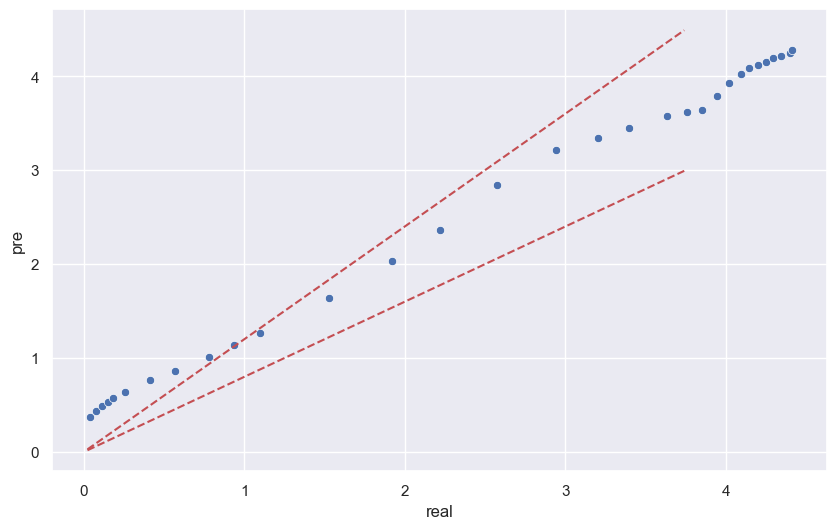

In [66]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='real', y='pre', data=adsorption_test_pre)
# Add 20% error lines
x_vals = np.linspace(select_pre['real'].min(), select_pre['real'].max(), 100)
plt.plot(x_vals, 1.2 * x_vals, 'r--', label='20% Over-prediction')
plt.plot(x_vals, 0.8 * x_vals, 'r--', label='20% Under-prediction')

/var/folders/lx/rz39m8ps1wg9pnrggcxk5w5r0000gn/T/ipykernel_84218/127134281.py:23: RuntimeWarning: overflow encountered in exp
  return qm * (P_bar * (ba * np.exp(Qa / (gs * T)))) / ((1 + ((ba * np.exp(Qa / (gs * T))) * P_bar) ** t0) ** (1 / t0))
/var/folders/lx/rz39m8ps1wg9pnrggcxk5w5r0000gn/T/ipykernel_84218/127134281.py:23: RuntimeWarning: invalid value encountered in divide
  return qm * (P_bar * (ba * np.exp(Qa / (gs * T)))) / ((1 + ((ba * np.exp(Qa / (gs * T))) * P_bar) ** t0) ** (1 / t0))
/var/folders/lx/rz39m8ps1wg9pnrggcxk5w5r0000gn/T/ipykernel_84218/127134281.py:23: RuntimeWarning: overflow encountered in power
  return qm * (P_bar * (ba * np.exp(Qa / (gs * T)))) / ((1 + ((ba * np.exp(Qa / (gs * T))) * P_bar) ** t0) ** (1 / t0))


Toth Model Parameters (Fitted using 283K, 298K, and 348K data): ba = 0.00003, Qa = 387.07782, t0 = 0.29960, qm = 7.29804
Deep Learning Model Error:
Mean Error: -0.10187
Max Error: 0.38993
Relative Error: 85.03%
MSE: 0.05086
R²: 0.98165
Toth Model Error (for 323K):
Mean Error: -0.02855
Max Error: 0.16193
Relative Error: 14.59%
MSE: 0.00411
R²: 0.99852


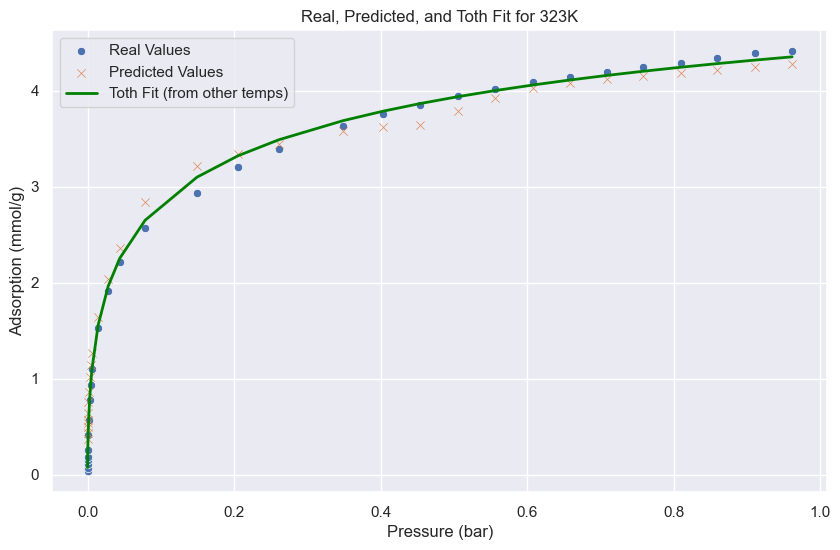

In [4]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score

# Fixed value: gas constant
gs = 0.0729019027

# Define Toth isotherm model
def toth_isotherm(P_bar, ba, Qa, t0, qm, T):
    """
    Toth isotherm model to calculate adsorption at different pressures.
    P_bar: Pressure (bar)
    ba: Adsorption equilibrium constant
    Qa: Adsorption energy
    t0: Exponent parameter of isotherm
    qm: Maximum adsorption capacity
    T: Temperature (K)
    """
    return qm * (P_bar * (ba * np.exp(Qa / (gs * T)))) / ((1 + ((ba * np.exp(Qa / (gs * T))) * P_bar) ** t0) ** (1 / t0))

# Load deep learning predictions and real values
adsorption_test_pre = pd.read_csv('predictions_gin_test_323.csv')

# Load data from the three temperatures used for fitting
files = {
    '283K': '吸附曲线用数据/fau-co2-283-1.csv',
    '298K': '吸附曲线用数据/fau-co2-298-1.csv',
    '348K': '吸附曲线用数据/fau-co2-348-1.csv'
}

# Initialize lists to store combined data for fitting
all_P = []
all_q_e = []
all_T = []

# Loop through each file and extract pressure and adsorption data
for temp_label, file in files.items():
    data = pd.read_csv(file)
    P_kPa = data['pressure'].values
    q_e = data['adsorption (CURLTUGMZLYLDI-UHFFFAOYSA-N)'].values
    T = int(temp_label.replace('K', ''))  # Extract temperature from the label

    all_P.extend(P_kPa)
    all_q_e.extend(q_e)
    all_T.extend([T] * len(P_kPa))  # Assign the temperature to each pressure point

# Convert the data into NumPy arrays for fitting
all_P = np.array(all_P)
all_q_e = np.array(all_q_e)
all_T = np.array(all_T)

# Initial guess for the parameters
initial_guess = [0.000001, 100, 10, 0.1]  # ba, Qa, t0, qm
bounds = (-np.inf, np.inf)

# Fit the Toth model using data from 283K, 298K, and 348K
popt_toth, _ = curve_fit(lambda P_T, ba, Qa, t0, qm: toth_isotherm(P_T[0], ba, Qa, t0, qm, P_T[1]), 
                         (all_P, all_T), all_q_e, p0=initial_guess, bounds=bounds, maxfev=80000)

# Extract fitted Toth parameters
ba, Qa, t0, qm = popt_toth
print(f"Toth Model Parameters (Fitted using 283K, 298K, and 348K data): ba = {ba:.5f}, Qa = {Qa:.5f}, t0 = {t0:.5f}, qm = {qm:.5f}")

# Load the 323K data for real adsorption
data_323K = pd.read_csv('吸附曲线用数据/fau-co2-323-1.csv')
P_323K = data_323K['pressure'].values
q_e_323K_real = data_323K['adsorption (CURLTUGMZLYLDI-UHFFFAOYSA-N)'].values
T_323K = 323  # 323K temperature

# Predict adsorption using the fitted Toth parameters for 323K
q_e_323K_toth = toth_isotherm(P_323K, ba, Qa, t0, qm, T_323K)

# Save Toth prediction data to a DataFrame
toth_data = pd.DataFrame({'Pressure (bar)': P_323K, 'Toth Prediction': q_e_323K_toth})

# Compute error between real values and deep learning prediction
real_values = adsorption_test_pre['real']
pred_values = adsorption_test_pre['pre']
pressure = adsorption_test_pre['Pressure (bar)']

mean_error_dl = np.mean(real_values - pred_values)
max_error_dl = np.max(np.abs(real_values - pred_values))
relative_error_dl = np.mean(np.abs((real_values - pred_values) / real_values)) * 100
mse_dl = mean_squared_error(real_values, pred_values)
r2_dl = r2_score(real_values, pred_values)

# Print deep learning model error
print(f"Deep Learning Model Error:")
print(f"Mean Error: {mean_error_dl:.5f}")
print(f"Max Error: {max_error_dl:.5f}")
print(f"Relative Error: {relative_error_dl:.2f}%")
print(f"MSE: {mse_dl:.5f}")
print(f"R²: {r2_dl:.5f}")

# Compute error between real values and Toth model prediction
mean_error_toth = np.mean(real_values - q_e_323K_toth)
max_error_toth = np.max(np.abs(real_values - q_e_323K_toth))
relative_error_toth = np.mean(np.abs((real_values - q_e_323K_toth) / real_values)) * 100
mse_toth = mean_squared_error(real_values, q_e_323K_toth)
r2_toth = r2_score(real_values, q_e_323K_toth)

# Print Toth model error
print(f"Toth Model Error (for 323K):")
print(f"Mean Error: {mean_error_toth:.5f}")
print(f"Max Error: {max_error_toth:.5f}")
print(f"Relative Error: {relative_error_toth:.2f}%")
print(f"MSE: {mse_toth:.5f}")
print(f"R²: {r2_toth:.5f}")

# Save errors for comparison
comparison_data = pd.DataFrame({
    'Pressure (bar)': pressure,
    'Real': real_values,
    'Deep Learning Prediction': pred_values,
    'Toth Prediction': q_e_323K_toth
})

# Plot the results: Real values, Deep Learning predictions, and Toth predictions
sns.set_theme(style='darkgrid')
plt.figure(figsize=(10, 6))

# Real values and predictions scatter plots
sns.scatterplot(x='Pressure (bar)', y='real', data=adsorption_test_pre, label='Real Values', marker='o')
sns.scatterplot(x='Pressure (bar)', y='pre', data=adsorption_test_pre, label='Predicted Values', marker='x')

# Toth model predictions line plot
sns.lineplot(x=P_323K, y=q_e_323K_toth, label='Toth Fit (from other temps)', color='green', linewidth=2)

# Set plot labels and title
plt.xlabel('Pressure (bar)')
plt.ylabel('Adsorption (mmol/g)')
plt.title('Real, Predicted, and Toth Fit for 323K')

# Add legend
plt.legend()

# Show plot
plt.show()

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

select_pre = pd.read_csv(r'../../newdata/归一化位置/反向之后/matched_predictions_with_database_new.csv')
print(len(select_pre['predicted']))
select_pre.head()

268


,predicted,real,Adsorption (mmol/g),zeolite_type,adsorbate,temperature
0,0.481274,0.483622,0.483616,TON,np,300
1,2.988178,3.062388,3.062450,AET,xp,303
2,3.048310,3.186342,3.186310,CHA,co2,298
3,2.423227,2.480906,2.480890,MFI,co2,303
4,0.915755,0.927701,0.927673,BOG,nb,300


Mean Error: 0.06813
Relative Error: 4.17%
MSE: 0.02060
R²: 0.99745


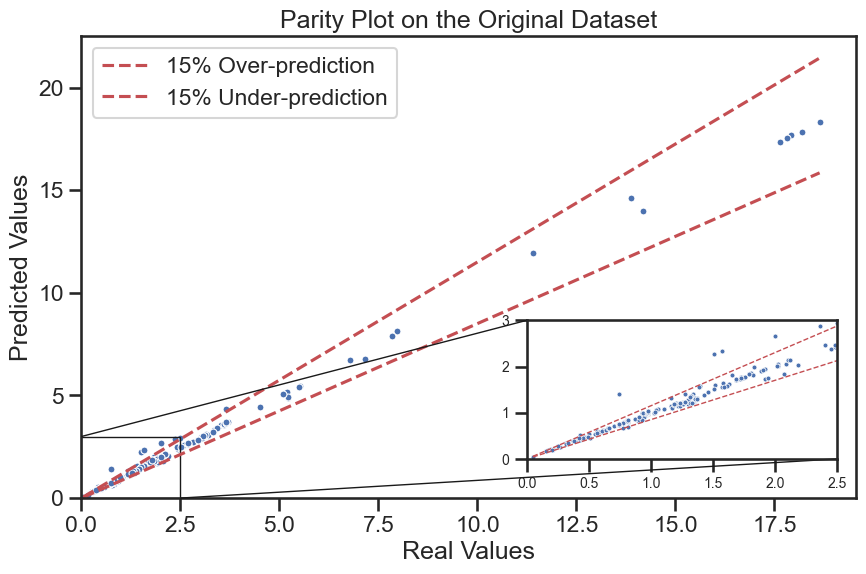

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

real_values = select_pre['Adsorption (mmol/g)']
pred_values = select_pre['predicted']
mean_error_dl = np.mean(abs(real_values - pred_values))
# max_error_dl = np.max(np.abs(real_values - pred_values))
relative_error_dl = np.mean(np.abs((real_values - pred_values) / real_values)) * 100
mse_dl = mean_squared_error(real_values, pred_values)
r2_dl = r2_score(real_values, pred_values)
print(f"Mean Error: {mean_error_dl:.5f}")
# print(f"Max Error: {max_error_dl:.5f}")
print(f"Relative Error: {relative_error_dl:.2f}%")
print(f"MSE: {mse_dl:.5f}")
print(f"R²: {r2_dl:.5f}")

# Set theme
sns.set_theme(style='ticks')
sns.set_context("talk")
# Create scatter plot with modifications
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.scatterplot(x='Adsorption (mmol/g)', y='predicted', data=select_pre,s=100, marker='.')

# Set labels
plt.xlabel('Real Values')
plt.ylabel('Predicted Values')
plt.title('Parity Plot on the Original Dataset')
# # Set log scale for both axes
# plt.xscale('log')
# plt.yscale('log')

# Add 20% error lines
x_vals = np.linspace(select_pre['Adsorption (mmol/g)'].min(), select_pre['Adsorption (mmol/g)'].max(), 100)
plt.plot(x_vals, 1.15 * x_vals, 'r--', label='15% Over-prediction')
plt.plot(x_vals, 0.85 * x_vals, 'r--', label='15% Under-prediction')
# Add legend
plt.legend()
# Set limits for zooming into a specific region (optional)
plt.xlim(0, None)
plt.ylim(0, None)
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
axins = inset_axes(ax, width="40%", height="30%",loc='lower left',
                   bbox_to_anchor=(0.56, 0.06, 1, 1),
                   bbox_transform=ax.transAxes)
# Real values and predictions scatter plots

sns.scatterplot(x='Adsorption (mmol/g)', y='predicted', data=select_pre,s=50, marker='.')
plt.plot(x_vals, 1.15 * x_vals, 'r--', label='15% Over-prediction',linewidth=1)
plt.plot(x_vals, 0.85 * x_vals, 'r--', label='15% Under-prediction',linewidth=1)

# 调整子坐标系的显示范围
axins.set_xlim(0, 2.5)
axins.set_ylim(0, 3)
# 建立父坐标系与子坐标系的连接线
# loc1 loc2: 坐标系的四个角
# 1 (右上) 2 (左上) 3(左下) 4(右下)
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec='k', lw=1)
plt.xlabel(None)
plt.ylabel(None)
plt.tick_params(labelsize=10)


# Show plot
plt.show()

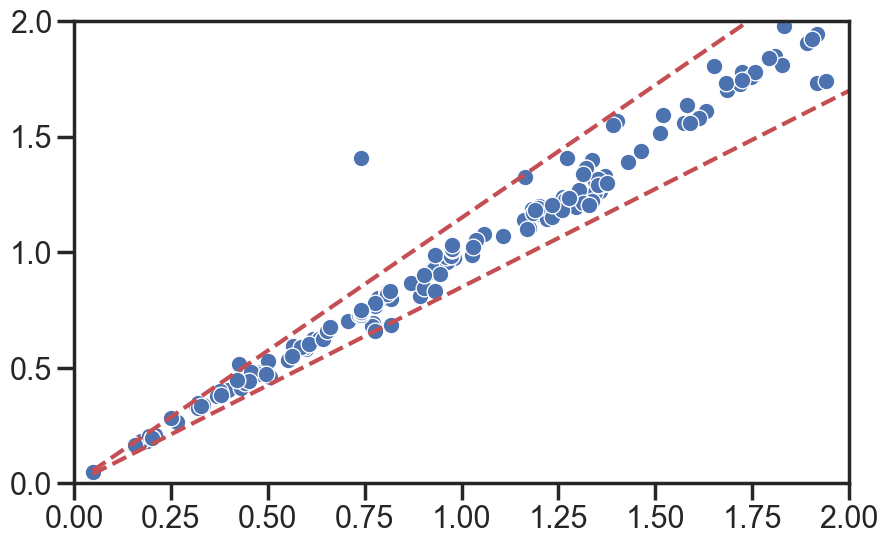

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set theme
sns.set_theme(style='ticks')
sns.set_context("poster")
# Create scatter plot with modifications
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Adsorption (mmol/g)', y='predicted', data=select_pre, marker='o')

# Set labels
plt.xlabel(None)
plt.ylabel(None)

# # Set log scale for both axes
# plt.xscale('log')
# plt.yscale('log')

# Add 20% error lines
x_vals = np.linspace(select_pre['Adsorption (mmol/g)'].min(), select_pre['Adsorption (mmol/g)'].max(), 100)
plt.plot(x_vals, 1.15 * x_vals, 'r--', label='15% Over-prediction')
plt.plot(x_vals, 0.85 * x_vals, 'r--', label='15% Under-prediction')

# Set limits for zooming into a specific region (optional)
plt.xlim(0, 2)
plt.ylim(0, 2)
# Add legend
# plt.legend()

# Show plot
plt.show()

In [3]:
adsorption_test_pre_baseline = pd.read_csv('../基线模型/model_predictions_数据增强后.csv')
adsorption_test_pre_baseline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Actual                        31 non-null     float64
 1   Linear Regression Prediction  31 non-null     float64
 2   MLP Prediction                31 non-null     float64
 3   Random Forest Prediction      31 non-null     float64
dtypes: float64(4)
memory usage: 1.1 KB


C:\Users\赵芃\AppData\Local\Temp\ipykernel_18792\3365772634.py:23: RuntimeWarning: overflow encountered in exp
  return qm * (P_bar * (ba * np.exp(Qa / (gs * T)))) / ((1 + ((ba * np.exp(Qa / (gs * T))) * P_bar) ** t0) ** (1 / t0))
C:\Users\赵芃\AppData\Local\Temp\ipykernel_18792\3365772634.py:23: RuntimeWarning: invalid value encountered in divide
  return qm * (P_bar * (ba * np.exp(Qa / (gs * T)))) / ((1 + ((ba * np.exp(Qa / (gs * T))) * P_bar) ** t0) ** (1 / t0))
C:\Users\赵芃\AppData\Local\Temp\ipykernel_18792\3365772634.py:23: RuntimeWarning: overflow encountered in power
  return qm * (P_bar * (ba * np.exp(Qa / (gs * T)))) / ((1 + ((ba * np.exp(Qa / (gs * T))) * P_bar) ** t0) ** (1 / t0))


Toth Model Parameters (Fitted using 283K, 298K, and 348K data): ba = 0.00003, Qa = 387.07782, t0 = 0.29960, qm = 7.29804
Deep Learning Model Error:
Mean Error: 0.04556
Max Error: 0.17117
Relative Error: 5.70%
MSE: 0.00415
R²: 0.99850
No smooth Deep Learning Model Error:
Mean Error: 0.27854
Max Error: 0.88855
Relative Error: 122.92%
MSE: 0.14275
R²: 0.94849
Toth Model Error (for 323K):
Mean Error: 0.05465
Max Error: 0.16194
Relative Error: 14.59%
MSE: 0.00411
R²: 0.99852


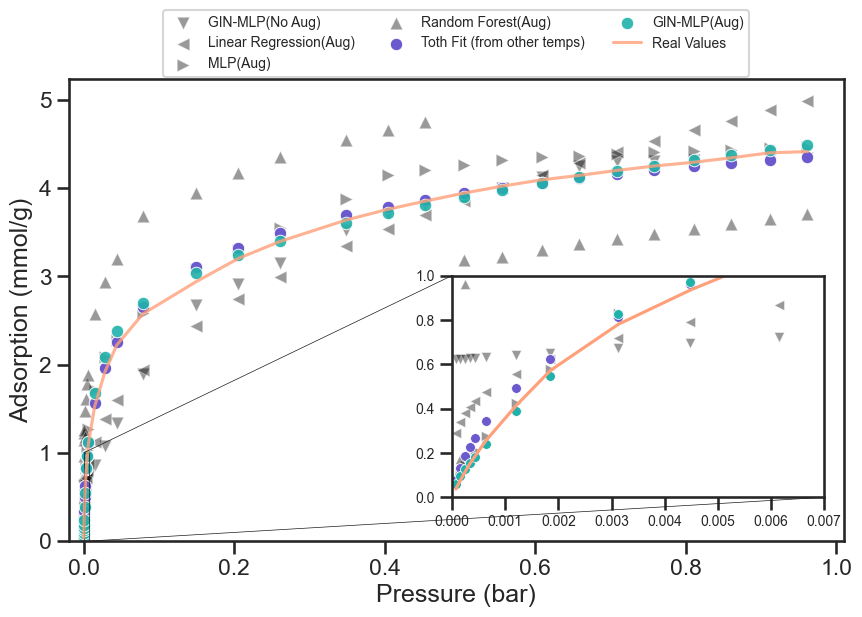

In [5]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score

# Fixed value: gas constant
gs = 0.0729019027

# Define Toth isotherm model
def toth_isotherm(P_bar, ba, Qa, t0, qm, T):
    """
    Toth isotherm model to calculate adsorption at different pressures.
    P_bar: Pressure (bar)
    ba: Adsorption equilibrium constant
    Qa: Adsorption energy
    t0: Exponent parameter of isotherm
    qm: Maximum adsorption capacity
    T: Temperature (K)
    """
    return qm * (P_bar * (ba * np.exp(Qa / (gs * T)))) / ((1 + ((ba * np.exp(Qa / (gs * T))) * P_bar) ** t0) ** (1 / t0))

# Load deep learning predictions and real values
adsorption_test_pre = pd.read_csv(r'../../newdata/归一化位置/反向之后/predictions_gin_test-1.csv')
adsorption_test_nosmooth = pd.read_csv(r'../../newdata/nosmooth/result/predictions_gin_test-1.csv')


# Load data from the three temperatures used for fitting
files = {
    '283K': '吸附曲线用数据/fau-co2-283-1.csv',
    '298K': '吸附曲线用数据/fau-co2-298-1.csv',
    '348K': '吸附曲线用数据/fau-co2-348-1.csv'
}

# Initialize lists to store combined data for fitting
all_P = []
all_q_e = []
all_T = []

# Loop through each file and extract pressure and adsorption data
for temp_label, file in files.items():
    data = pd.read_csv(file)
    P_kPa = data['pressure'].values
    q_e = data['adsorption (CURLTUGMZLYLDI-UHFFFAOYSA-N)'].values
    T = int(temp_label.replace('K', ''))  # Extract temperature from the label

    all_P.extend(P_kPa)
    all_q_e.extend(q_e)
    all_T.extend([T] * len(P_kPa))  # Assign the temperature to each pressure point

# Convert the data into NumPy arrays for fitting
all_P = np.array(all_P)
all_q_e = np.array(all_q_e)
all_T = np.array(all_T)

# Initial guess for the parameters
initial_guess = [0.000001, 100, 10, 0.1]  # ba, Qa, t0, qm
bounds = (-np.inf, np.inf)

# Fit the Toth model using data from 283K, 298K, and 348K
popt_toth, _ = curve_fit(lambda P_T, ba, Qa, t0, qm: toth_isotherm(P_T[0], ba, Qa, t0, qm, P_T[1]), 
                         (all_P, all_T), all_q_e, p0=initial_guess, bounds=bounds, maxfev=80000)

# Extract fitted Toth parameters
ba, Qa, t0, qm = popt_toth
print(f"Toth Model Parameters (Fitted using 283K, 298K, and 348K data): ba = {ba:.5f}, Qa = {Qa:.5f}, t0 = {t0:.5f}, qm = {qm:.5f}")

# Load the 323K data for real adsorption
data_323K = pd.read_csv('吸附曲线用数据/fau-co2-323-1.csv')
P_323K = data_323K['pressure'].values
q_e_323K_real = data_323K['adsorption (CURLTUGMZLYLDI-UHFFFAOYSA-N)'].values
T_323K = 323  # 323K temperature

# Predict adsorption using the fitted Toth parameters for 323K
q_e_323K_toth = toth_isotherm(P_323K, ba, Qa, t0, qm, T_323K)

# Save Toth prediction data to a DataFrame
toth_data = pd.DataFrame({'Pressure (bar)': P_323K, 'Toth Prediction': q_e_323K_toth})

# Compute error between real values and deep learning prediction
real_values = adsorption_test_pre['real']
pred_values = adsorption_test_pre['pre']
pressure = adsorption_test_pre['Pressure (bar)']

mean_error_dl = np.mean(abs(real_values - pred_values))
max_error_dl = np.max(np.abs(real_values - pred_values))
relative_error_dl = np.mean(np.abs((real_values - pred_values) / real_values)) * 100
mse_dl = mean_squared_error(real_values, pred_values)
r2_dl = r2_score(real_values, pred_values)

# Print deep learning model error
print(f"Deep Learning Model Error:")
print(f"Mean Error: {mean_error_dl:.5f}")
print(f"Max Error: {max_error_dl:.5f}")
print(f"Relative Error: {relative_error_dl:.2f}%")
print(f"MSE: {mse_dl:.5f}")
print(f"R²: {r2_dl:.5f}")

pred_values_nosmooth = adsorption_test_nosmooth['pre']

mean_error_dl = np.mean(abs(real_values - pred_values_nosmooth))
max_error_dl = np.max(np.abs(real_values - pred_values_nosmooth))
relative_error_dl = np.mean(np.abs((real_values - pred_values_nosmooth) / real_values)) * 100
mse_dl = mean_squared_error(real_values, pred_values_nosmooth)
r2_dl = r2_score(real_values, pred_values_nosmooth)

# Print deep learning model error
print(f"No smooth Deep Learning Model Error:")
print(f"Mean Error: {mean_error_dl:.5f}")
print(f"Max Error: {max_error_dl:.5f}")
print(f"Relative Error: {relative_error_dl:.2f}%")
print(f"MSE: {mse_dl:.5f}")
print(f"R²: {r2_dl:.5f}")


# Compute error between real values and Toth model prediction
mean_error_toth = np.mean(abs(real_values - q_e_323K_toth))
max_error_toth = np.max(np.abs(real_values - q_e_323K_toth))
relative_error_toth = np.mean(np.abs((real_values - q_e_323K_toth) / real_values)) * 100
mse_toth = mean_squared_error(real_values, q_e_323K_toth)
r2_toth = r2_score(real_values, q_e_323K_toth)

# Print Toth model error
print(f"Toth Model Error (for 323K):")
print(f"Mean Error: {mean_error_toth:.5f}")
print(f"Max Error: {max_error_toth:.5f}")
print(f"Relative Error: {relative_error_toth:.2f}%")
print(f"MSE: {mse_toth:.5f}")
print(f"R²: {r2_toth:.5f}")

LR_pre = adsorption_test_pre_baseline['Linear Regression Prediction']
MLP_pre = adsorption_test_pre_baseline['MLP Prediction']
RF_pre = adsorption_test_pre_baseline['Random Forest Prediction']

# Save errors for comparison
comparison_data = pd.DataFrame({
    'Pressure (bar)': pressure,
    'Real': real_values,
    'Deep Learning Prediction': pred_values,
    'Toth Prediction': q_e_323K_toth
})

# Plot the results: Real values, Deep Learning predictions, and Toth predictions
sns.set_theme(style='ticks')
sns.set_context("talk")
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Real values and predictions scatter plots
# Toth model predictions line plot

sns.scatterplot(x='Pressure (bar)', y='pre', data=adsorption_test_nosmooth,color='black', label='GIN-MLP(No Aug)', marker='v',alpha=0.4)
sns.scatterplot(x=pressure, y=LR_pre,color='black', label='Linear Regression(Aug)', marker='<',alpha=0.4)
sns.scatterplot(x=pressure, y=MLP_pre,color='black', label='MLP(Aug)', marker='>',alpha=0.4)
sns.scatterplot(x=pressure, y=RF_pre,color='black', label='Random Forest(Aug)', marker='^',alpha=0.4)
sns.scatterplot(x=P_323K, y=q_e_323K_toth,color='slateblue', label='Toth Fit (from other temps)', marker='o',alpha=1)#, linewidth=2)
sns.scatterplot(x='Pressure (bar)', y='pre',color='lightseagreen', data=adsorption_test_pre, label='GIN-MLP(Aug)', marker='o',alpha=0.9)
sns.lineplot(x='Pressure (bar)', y='real',color='lightsalmon', data=adsorption_test_pre, label='Real Values',alpha=0.8)#sns.scatterplot(x='Pressure (bar)', y='real',color='lightsalmon', data=adsorption_test_pre, label='Real Values', marker='o',alpha=0.8)



# Set plot labels and title
plt.xlabel('Pressure (bar)')
plt.ylabel('Adsorption (mmol/g)')
# plt.title('Real, Predicted, and Toth Fit for 323K')
plt.xlim(-0.02,None)
plt.ylim(0,None)

# Add legend
plt. legend (fontsize=10,bbox_to_anchor=( 0.5 , 1.15 ), loc='upper center', borderaxespad= 0, ncol=3 ) 

from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
axins = inset_axes(ax, width="40%", height="40%",loc='lower left',
                   bbox_to_anchor=(0.48, 0.07, 1.2, 1.2),
                   bbox_transform=ax.transAxes)
# Real values and predictions scatter plots
# Toth model predictions line plot

sns.scatterplot(x='Pressure (bar)', y='pre', data=adsorption_test_nosmooth,s=50,color='black', marker='v',alpha=0.4)
sns.scatterplot(x=pressure, y=LR_pre, s=50,color='black', marker='<',alpha=0.4)
sns.scatterplot(x=pressure, y=MLP_pre, s=50,color='black',  marker='>',alpha=0.4)
sns.scatterplot(x=pressure, y=RF_pre, s=50,color='black',  marker='^',alpha=0.4)
sns.scatterplot(x=P_323K, y=q_e_323K_toth,s=50,color='slateblue',  marker='o')#, linewidth=2)
sns.scatterplot(x='Pressure (bar)', y='pre', data=adsorption_test_pre,s=50,color='lightseagreen', marker='o')
sns.lineplot(x='Pressure (bar)', y='real', data=adsorption_test_pre,color='lightsalmon')#sns.scatterplot(x='Pressure (bar)', y='real', data=adsorption_test_pre,s=50,color='lightsalmon',  marker='o')


# 设置放大区间
zone_left = 11
zone_right = 12

# 坐标轴的扩展比例（根据实际数据调整）
x_ratio = 1.2 # x轴显示范围的扩展比例
y_ratio = 0.8 # y轴显示范围的扩展比例

# X轴的显示范围
xlim0 = pressure[zone_left]-(pressure[zone_right]-pressure[zone_left])*x_ratio
xlim1 = pressure[zone_right]+(pressure[zone_right]-pressure[zone_left])*x_ratio

# Y轴的显示范围
y = np.hstack((real_values[zone_left:zone_right], pred_values[zone_left:zone_right], pred_values_nosmooth[zone_left:zone_right], q_e_323K_toth[zone_left:zone_right]))
ylim0 = np.min(y)-(np.max(y)-np.min(y))*y_ratio
ylim1 = np.max(y)+(np.max(y)-np.min(y))*y_ratio

# 调整子坐标系的显示范围
axins.set_xlim(0, 0.007)
axins.set_ylim(0, 1)
# 建立父坐标系与子坐标系的连接线
# loc1 loc2: 坐标系的四个角
# 1 (右上) 2 (左上) 3(左下) 4(右下)
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec='k', lw=0.5)
plt.xlabel(None)
plt.ylabel(None)
plt.tick_params(labelsize=10)

# Show plot
plt.show()

/var/folders/lx/rz39m8ps1wg9pnrggcxk5w5r0000gn/T/ipykernel_67212/1605775730.py:23: RuntimeWarning: overflow encountered in exp
  return qm * (P_bar * (ba * np.exp(Qa / (gs * T)))) / ((1 + ((ba * np.exp(Qa / (gs * T))) * P_bar) ** t0) ** (1 / t0))
/var/folders/lx/rz39m8ps1wg9pnrggcxk5w5r0000gn/T/ipykernel_67212/1605775730.py:23: RuntimeWarning: invalid value encountered in divide
  return qm * (P_bar * (ba * np.exp(Qa / (gs * T)))) / ((1 + ((ba * np.exp(Qa / (gs * T))) * P_bar) ** t0) ** (1 / t0))
/var/folders/lx/rz39m8ps1wg9pnrggcxk5w5r0000gn/T/ipykernel_67212/1605775730.py:23: RuntimeWarning: overflow encountered in power
  return qm * (P_bar * (ba * np.exp(Qa / (gs * T)))) / ((1 + ((ba * np.exp(Qa / (gs * T))) * P_bar) ** t0) ** (1 / t0))


Toth Model Parameters (Fitted using 283K, 298K, and 348K data): ba = 0.00003, Qa = 387.07782, t0 = 0.29960, qm = 7.29804
Deep Learning Model Error:
Mean Error: -0.02279
Max Error: 0.17117
Relative Error: 5.70%
MSE: 0.00415
R²: 0.99850
No smooth Deep Learning Model Error:
Mean Error: 0.04698
Max Error: 0.88855
Relative Error: 122.92%
MSE: 0.14275
R²: 0.94849
Toth Model Error (for 323K):
Mean Error: -0.02855
Max Error: 0.16194
Relative Error: 14.59%
MSE: 0.00411
R²: 0.99852


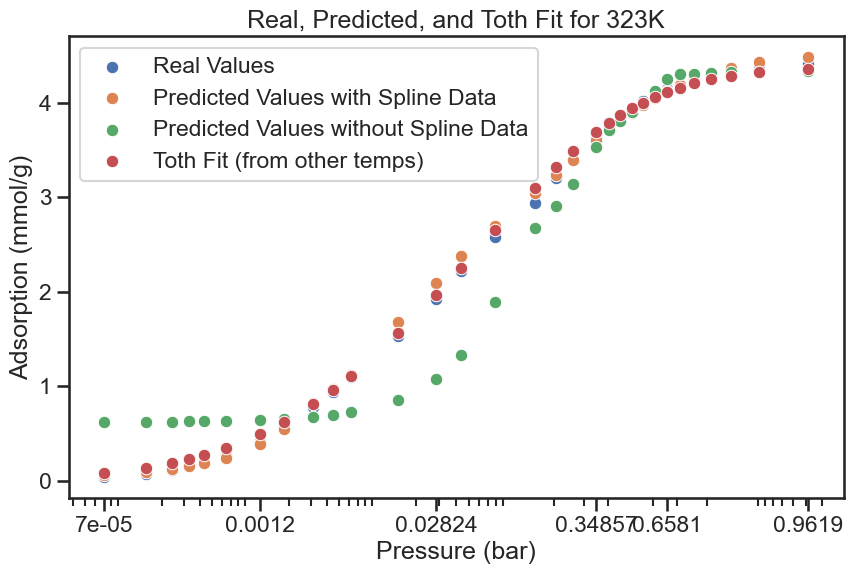

In [98]:

# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score

# Fixed value: gas constant
gs = 0.0729019027

# Define Toth isotherm model
def toth_isotherm(P_bar, ba, Qa, t0, qm, T):
    """
    Toth isotherm model to calculate adsorption at different pressures.
    P_bar: Pressure (bar)
    ba: Adsorption equilibrium constant
    Qa: Adsorption energy
    t0: Exponent parameter of isotherm
    qm: Maximum adsorption capacity
    T: Temperature (K)
    """
    return qm * (P_bar * (ba * np.exp(Qa / (gs * T)))) / ((1 + ((ba * np.exp(Qa / (gs * T))) * P_bar) ** t0) ** (1 / t0))

# Load deep learning predictions and real values
adsorption_test_pre = pd.read_csv(r'../../newdata/归一化位置/反向之后/predictions_gin_test-1.csv')
adsorption_test_nosmooth = pd.read_csv(r'../../newdata/nosmooth/result/predictions_gin_test-1.csv')

# Load data from the three temperatures used for fitting
files = {
    '283K': '吸附曲线用数据/fau-co2-283-1.csv',
    '298K': '吸附曲线用数据/fau-co2-298-1.csv',
    '348K': '吸附曲线用数据/fau-co2-348-1.csv'
}

# Initialize lists to store combined data for fitting
all_P = []
all_q_e = []
all_T = []

# Loop through each file and extract pressure and adsorption data
for temp_label, file in files.items():
    data = pd.read_csv(file)
    P_kPa = data['pressure'].values
    q_e = data['adsorption (CURLTUGMZLYLDI-UHFFFAOYSA-N)'].values
    T = int(temp_label.replace('K', ''))  # Extract temperature from the label

    all_P.extend(P_kPa)
    all_q_e.extend(q_e)
    all_T.extend([T] * len(P_kPa))  # Assign the temperature to each pressure point

# Convert the data into NumPy arrays for fitting
all_P = np.array(all_P)
all_q_e = np.array(all_q_e)
all_T = np.array(all_T)

# Initial guess for the parameters
initial_guess = [0.000001, 100, 10, 0.1]  # ba, Qa, t0, qm
bounds = (-np.inf, np.inf)

# Fit the Toth model using data from 283K, 298K, and 348K
popt_toth, _ = curve_fit(lambda P_T, ba, Qa, t0, qm: toth_isotherm(P_T[0], ba, Qa, t0, qm, P_T[1]), 
                         (all_P, all_T), all_q_e, p0=initial_guess, bounds=bounds, maxfev=80000)

# Extract fitted Toth parameters
ba, Qa, t0, qm = popt_toth
print(f"Toth Model Parameters (Fitted using 283K, 298K, and 348K data): ba = {ba:.5f}, Qa = {Qa:.5f}, t0 = {t0:.5f}, qm = {qm:.5f}")

# Load the 323K data for real adsorption
data_323K = pd.read_csv('吸附曲线用数据/fau-co2-323-1.csv')
P_323K = data_323K['pressure'].values
q_e_323K_real = data_323K['adsorption (CURLTUGMZLYLDI-UHFFFAOYSA-N)'].values
T_323K = 323  # 323K temperature

# Predict adsorption using the fitted Toth parameters for 323K
q_e_323K_toth = toth_isotherm(P_323K, ba, Qa, t0, qm, T_323K)

# Save Toth prediction data to a DataFrame
toth_data = pd.DataFrame({'Pressure (bar)': P_323K, 'Toth Prediction': q_e_323K_toth})

# Compute error between real values and deep learning prediction
real_values = adsorption_test_pre['real']
pred_values = adsorption_test_pre['pre']
pressure = adsorption_test_pre['Pressure (bar)']

mean_error_dl = np.mean(real_values - pred_values)
max_error_dl = np.max(np.abs(real_values - pred_values))
relative_error_dl = np.mean(np.abs((real_values - pred_values) / real_values)) * 100
mse_dl = mean_squared_error(real_values, pred_values)
r2_dl = r2_score(real_values, pred_values)

# Print deep learning model error
print(f"Deep Learning Model Error:")
print(f"Mean Error: {mean_error_dl:.5f}")
print(f"Max Error: {max_error_dl:.5f}")
print(f"Relative Error: {relative_error_dl:.2f}%")
print(f"MSE: {mse_dl:.5f}")
print(f"R²: {r2_dl:.5f}")

pred_values_nosmooth = adsorption_test_nosmooth['pre']

mean_error_dl = np.mean(real_values - pred_values_nosmooth)
max_error_dl = np.max(np.abs(real_values - pred_values_nosmooth))
relative_error_dl = np.mean(np.abs((real_values - pred_values_nosmooth) / real_values)) * 100
mse_dl = mean_squared_error(real_values, pred_values_nosmooth)
r2_dl = r2_score(real_values, pred_values_nosmooth)

# Print deep learning model error
print(f"No smooth Deep Learning Model Error:")
print(f"Mean Error: {mean_error_dl:.5f}")
print(f"Max Error: {max_error_dl:.5f}")
print(f"Relative Error: {relative_error_dl:.2f}%")
print(f"MSE: {mse_dl:.5f}")
print(f"R²: {r2_dl:.5f}")


# Compute error between real values and Toth model prediction
mean_error_toth = np.mean(real_values - q_e_323K_toth)
max_error_toth = np.max(np.abs(real_values - q_e_323K_toth))
relative_error_toth = np.mean(np.abs((real_values - q_e_323K_toth) / real_values)) * 100
mse_toth = mean_squared_error(real_values, q_e_323K_toth)
r2_toth = r2_score(real_values, q_e_323K_toth)

# Print Toth model error
print(f"Toth Model Error (for 323K):")
print(f"Mean Error: {mean_error_toth:.5f}")
print(f"Max Error: {max_error_toth:.5f}")
print(f"Relative Error: {relative_error_toth:.2f}%")
print(f"MSE: {mse_toth:.5f}")
print(f"R²: {r2_toth:.5f}")

# Save errors for comparison
comparison_data = pd.DataFrame({
    'Pressure (bar)': pressure,
    'Real': real_values,
    'Deep Learning Prediction': pred_values,
    'Toth Prediction': q_e_323K_toth
})

# Plot the results: Real values, Deep Learning predictions, and Toth predictions
sns.set_theme(style='ticks')
sns.set_context("talk")
plt.figure(figsize=(10, 6))

# Real values and predictions scatter plots
sns.scatterplot(x='Pressure (bar)', y='real', data=adsorption_test_pre, label='Real Values', marker='o')
sns.scatterplot(x='Pressure (bar)', y='pre', data=adsorption_test_pre, label='Predicted Values with Spline Data', marker='o')
sns.scatterplot(x='Pressure (bar)', y='pre', data=adsorption_test_nosmooth, label='Predicted Values without Spline Data', marker='o')

# Toth model predictions line plot
sns.scatterplot(x=P_323K, y=q_e_323K_toth, label='Toth Fit (from other temps)', marker='o')#, linewidth=2)


# Set plot labels and title
plt.xlabel('Pressure (bar)')
plt.ylabel('Adsorption (mmol/g)')
plt.title('Real, Predicted, and Toth Fit for 323K')
# plt.xlim(0,0.02)
# Set log scale for both axes
plt.xscale('logit')
# 定义所有可能的 x 坐标刻度和标签
selected_ticks = pressure
selected_labels = [f'{xi}' for xi in selected_ticks]

# 选择性地减少要显示的刻度数量 (每隔 2 个显示一个)
# 例如：通过 slice 方法
reduced_ticks = selected_ticks[::6]      # 每隔2个刻度点显示一个
reduced_labels = selected_labels[::6]    # 对应的标签也减少

# 手动设置 x 轴的刻度和标签
plt.xticks(reduced_ticks, labels=reduced_labels)
# 使用 MaxNLocator 自动控制标签的数量

# plt.yscale('log')
# Add legend
plt.legend()

# Show plot
plt.show()